In [1]:
#get all the tables:
from db_setup import conn, currencyexchange, customer, date, product, sales, store
#instead of saving csv files in sql and then importing one by one
import pandas as pd
import numpy as np

customer_summary=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_summary.parquet")
order_enriched=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\order_enriched.parquet")


c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  currencyexchange = pd.read_sql("SELECT * FROM currencyexchange", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer = pd.read_sql("SELECT * FROM customer", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  date = pd.read_sql("SELECT * FR

1- overall delivery stats:

In [2]:
delivery_days=order_enriched["delivery_days"].dropna()

avg_delivery=delivery_days.mean()
median_delivery=delivery_days.median()
p90_delivery=np.percentile(delivery_days,90)
#or using pandas: delivery_days.quantile(0.90)
max_delivery=delivery_days.max()

delivery_stats={
    "avg_delivery_days":round(avg_delivery,2),
    "median_delivery_days": round(median_delivery, 2),
    "p90_delivery_days": round(p90_delivery, 2),
    "max_delivery_days": max_delivery
}

delivery_stats


{'avg_delivery_days': np.float64(1.3),
 'median_delivery_days': 0.0,
 'p90_delivery_days': np.float64(4.0),
 'max_delivery_days': 19}

2 - Delivery performance by country

In [ ]:
country_delivery = (
    order_enriched
    .groupby("customer_country")
    .agg(
        orders=("delivery_days", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        p90_delivery_days=("delivery_days", lambda x: np.percentile(x, 90))
    )
    .round(2)
    .sort_values("avg_delivery_days", ascending=False)
)

# country_delivery[["avg_delivery_days", "median_delivery_days", "p90_delivery_days"]] = (
#     country_delivery[["avg_delivery_days", "median_delivery_days", "p90_delivery_days"]].round(2)
# ) -- usually best to round only the relevant columns instead of the whole df like i did above.

country_delivery

,orders,avg_delivery_days,median_delivery_days,p90_delivery_days
customer_country,,,,
France,2597,1.44,0.0,4.0
Australia,4937,1.35,0.0,4.0
Germany,8888,1.33,0.0,4.0
Netherlands,3483,1.32,0.0,4.0
United States,43531,1.31,0.0,4.0
Canada,8717,1.30,0.0,4.0
United Kingdom,8578,1.18,0.0,4.0
Italy,2399,1.15,0.0,4.0


3- Delivery distribution buckets

In [ ]:
bins = [0,3,7,14,30,100]

labels = ["0–3 days","4–7 days","8–14 days","15–30 days","30+ days"]

order_enriched["delivery_bucket"] = pd.cut(

    order_enriched["delivery_days"], 
    bins=bins,
    labels=labels, 
    right=True, 
    include_lowest=True 

)

delivery_distribution = (
    order_enriched
    .groupby("delivery_bucket")
    .size()
    .reset_index(name="orders")
)

delivery_distribution["pct_orders"] = (
    delivery_distribution["orders"] / 
    delivery_distribution["orders"].sum() * 100
).round(2)

delivery_distribution

C:\Users\amyre\AppData\Local\Temp\ipykernel_39052\34950309.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("delivery_bucket")#,observed=True)


,delivery_bucket,orders,pct_orders
0,0–3 days,70440,84.73
1,4–7 days,11887,14.30
2,8–14 days,782,0.94
3,15–30 days,21,0.03
4,30+ days,0,0.00


Graphs:

Avg delivery days by country:

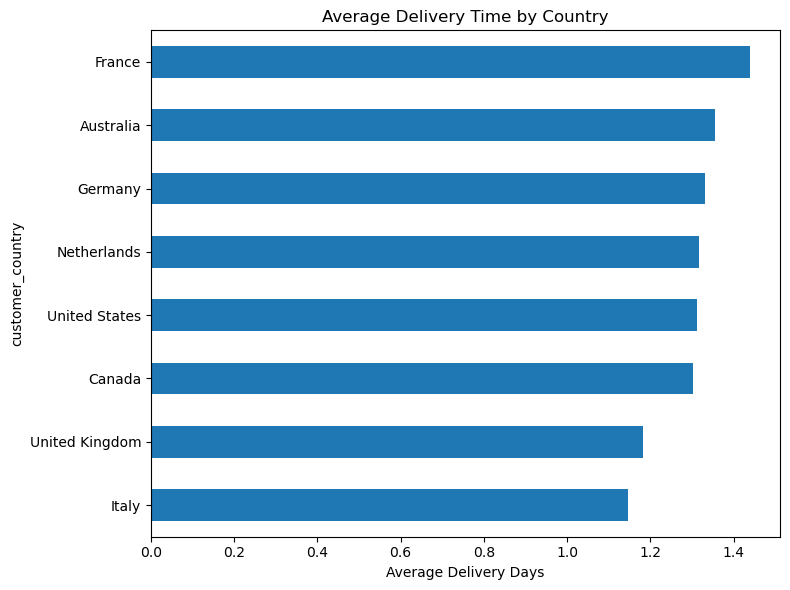

In [ ]:
import matplotlib.pyplot as plt

country_delivery = order_enriched.groupby("customer_country")["delivery_days"].mean().sort_values()

plt.figure(figsize=(8,6))
country_delivery.plot(kind="barh")

plt.xlabel("Average Delivery Days")
plt.title("Average Delivery Time by Country")
plt.tight_layout()

Histogram delivery days distribution

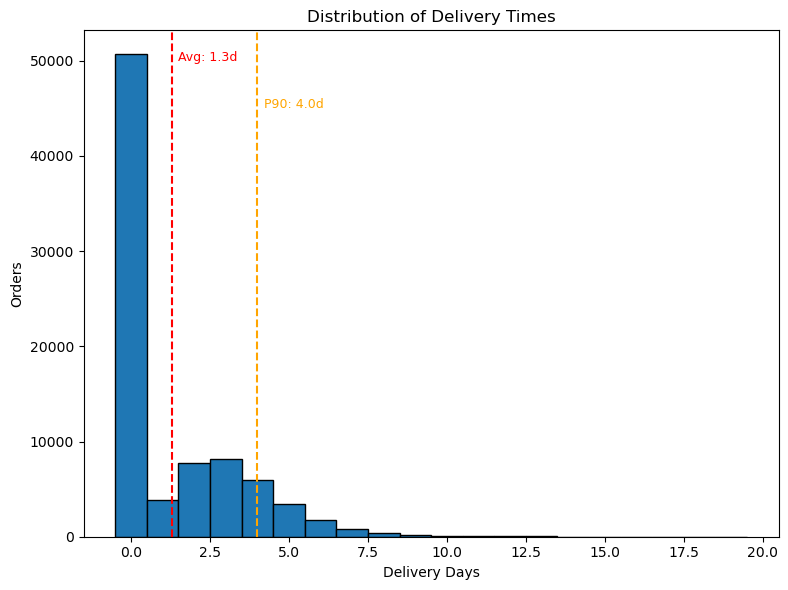

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    order_enriched["delivery_days"].dropna(),
    bins=range(0,21),
    edgecolor="black",
    align="left"
)

plt.axvline(avg_delivery, color="red", linestyle="--", 
    linewidth=1.5, label=f"Avg: {avg_delivery:.1f} days")
plt.text(
    avg_delivery + 0.2,  
    50000,  
    f"Avg: {avg_delivery:.1f}d",
    color="red",
    fontsize=9
)
plt.axvline(p90_delivery, color="orange", linestyle="--", 
    linewidth=1.5, label=f"P90: {p90_delivery:.1f} days")
plt.text(
    p90_delivery + 0.2,
    45000, 
    f"P90: {p90_delivery:.1f}d",
    color="orange",
    fontsize=9
)

plt.xlabel("Delivery Days")
plt.ylabel("Orders")
plt.title("Distribution of Delivery Times")

plt.tight_layout()
